# Krylov-Parameter untersuchen

In [5]:
import import_ipynb
import numpy as np
import matplotlib.pyplot as plt
from main_non_markov import res, t_fs, N, out_B, MODEL, dt_fs, HEOM_depth
from non_markov_circuit import propagate_memory_shots, propagate_memory_density_matrix, propagate_memory_classical
from non_markov_E_in_eigener_file import calculate_heom_propagator, _make_solver, heom_onestep_propagator, transfer_tensors, companion_propagator, heom_shorttime_maps

In [ ]:
# Krylov-Parameter untersuchen (Referenz: QuTiP exakt)

if 'HEOM_exakt (QuTiP)' in out_B:
    pops_qutip = out_B['HEOM_exakt (QuTiP)'][0]
else:
    raise ValueError("Bitte zuerst die Zelle mit der QuTiP-Referenz ausführen!")

source_name = 'HEOM'
E, K = res[source_name]['E'], res[source_name]['K']
X0 = np.concatenate([res[source_name]['rho'][i].flatten(order='F') for i in range(K)][::-1])

# Referenz-Slicing für den propagierten Bereich ab t_{K-1}
ref_pops_qutip = pops_qutip[K - 1:]

# Optional: Reiner TT-Fensterfehler ohne Krylov als Baseline-Fehlergrenze
tt_exact_pops = res[source_name]['pops'][K - 1:]
tt_baseline_error = np.abs(tt_exact_pops - ref_pops_qutip).max()

# Eindeutige Integer-Werte zwischen 1 und 60 generieren
m_values = np.unique(np.linspace(1, 10, 10, dtype=int))
errors = []
success_probs = []

M_KRYLOV   | Max Error vs QuTiP   | p_success    | ||H_m||   
------------------------------------------------------------


1          | 3.90e-01             | 1.000e+00    | 0.9709    
2          | 6.47e-01             | 9.766e-04    | 0.9927    
3          | 1.92e-01             | 6.494e-01    | 0.9959    
4          | 2.28e-01             | 1.357e-01    | 0.9972    
5          | 1.80e-01             | 6.797e-01    | 0.9973    
6          | 1.62e-01             | 3.271e-01    | 0.9978    
7          | 1.64e-01             | 4.854e-01    | 0.9997    
8          | 1.53e-01             | 1.973e-01    | 1.0037    
9          | 1.34e-01             | 1.064e-01    | 1.0057    
10         | 1.29e-01             | 8.105e-02    | 1.0074    


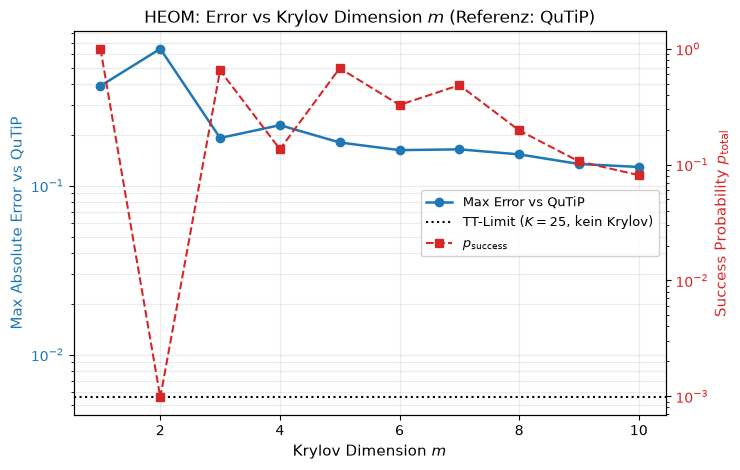

In [7]:
print(f"{'M_KRYLOV':<10} | {'Max Error vs QuTiP':<20} | {'p_success':<12} | {'||H_m||':<10}")
print("-" * 60)

for m_val in m_values:
    # Simulation mit aktuellem M_KRYLOV ausführen
    pops, qc, info = propagate_memory_density_matrix(E, X0, len(t_fs) - K, int(m_val), N)
    
    # Maximalen absoluten Fehler direkt zur QuTiP-Referenz berechnen
    err = np.abs(pops - ref_pops_qutip).max()
    errors.append(err)
    success_probs.append(info.get('p_success', 1.0))
    
    print(f"{m_val:<10d} | {err:<20.2e} | {info.get('p_success', 1.0):<12.3e} | {info['norm_Hm']:<10.4f}")

# Fehlerverlauf plotten
fig, ax1 = plt.subplots(figsize=(7.5, 4.8))

col_err = '#1f77b4'
col_p = '#d62728'

line1 = ax1.semilogy(m_values, errors, color=col_err, marker='o', lw=1.8, label='Max Error vs QuTiP')
line_base = ax1.axhline(y=tt_baseline_error, color='black', linestyle=':', lw=1.5, 
                        label=f'TT-Limit ($K={K}$, kein Krylov)')

ax1.set_xlabel(r'Krylov Dimension $m$', fontsize=11)
ax1.set_ylabel('Max Absolute Error vs QuTiP', color=col_err, fontsize=11)
ax1.tick_params(axis='y', labelcolor=col_err)
ax1.grid(True, which='both', alpha=0.25)

# Zweite y-Achse für Erfolgswahrscheinlichkeit
ax2 = ax1.twinx()
line2 = ax2.semilogy(m_values, success_probs, color=col_p, marker='s', ls='--', lw=1.5, label=r'$p_{\mathrm{success}}$')
ax2.set_ylabel(r'Success Probability $p_{\mathrm{total}}$', color=col_p, fontsize=11)
ax2.tick_params(axis='y', labelcolor=col_p)

# Zusammengeführte Legende
lines = line1 + [line_base] + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right', frameon=True, framealpha=0.9, fontsize=9.5)

plt.title(rf'{source_name}: Error vs Krylov Dimension $m$ (Referenz: QuTiP)', fontsize=12)
fig.tight_layout()
plt.show()

## Das Optimum von $m$: beide Fehler zusammen

Die Zelle oben zeigt Algorithmusfehler und $p_{\rm success}$ getrennt — und beide
sprechen fuer entgegengesetzte $m$. Entscheidend ist aber ihre **Summe**.

Der Algorithmusfehler faellt mit $m$ und saettigt dann auf dem TT-Limit (dort
begrenzt das Gedaechtnisfenster $K$, nicht mehr Arnoldi). Der statistische
Fehler waechst mit $m$, weil $\Vert H_m\Vert_2$ steigt, sobald Arnoldi ueber die
physikalisch besuchte Bahn hinausgreift, und die Nachselektion mit
$s^{-2n}$ bezahlt wird:

$$\varepsilon_{\rm stat} \approx \frac{1}{2\sqrt{N_{\rm shots}\, p_{\rm success}}},
\qquad
\varepsilon_{\rm ges} = \sqrt{\varepsilon_{\rm algo}^2 + \varepsilon_{\rm stat}^2}$$

Diese Zelle setzt `m_values`, `errors` und `success_probs` aus der Zelle oben
voraus und rechnet nichts neu.

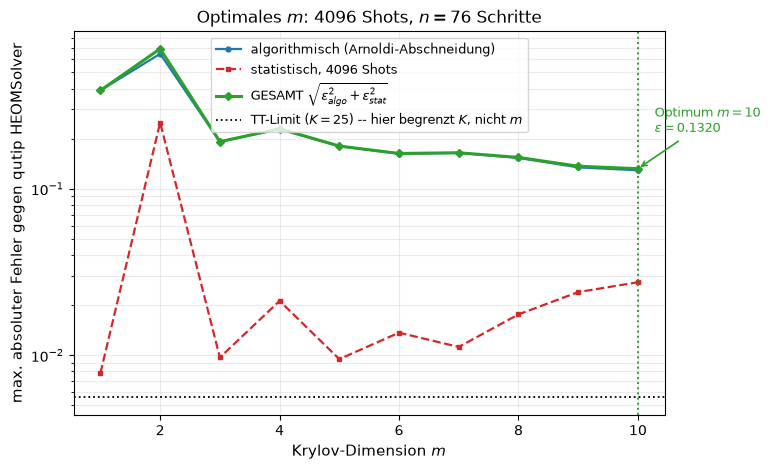

     m     p_succ    N_acc |      algo      stat    GESAMT
     8  1.973e-01    808.0 |   0.15325   0.01759   0.15426

  Optimum bei m = 10, Gesamtfehler 0.13197


In [8]:
SHOTS = 4096          # Shot-Budget je Auslesepunkt

for _v in ('m_values', 'errors', 'success_probs'):
    if _v not in dir():
        raise NameError(f"'{_v}' fehlt -- bitte zuerst die m-Scan-Zelle oben ausfuehren.")

m_arr  = np.asarray(m_values, float)
e_algo = np.asarray(errors, float)
p_succ = np.asarray(success_probs, float)

n_acc   = SHOTS * p_succ
e_stat  = np.where(n_acc >= 1.0, 1.0 / (2.0 * np.sqrt(np.maximum(n_acc, 1e-300))), np.inf)
e_total = np.sqrt(e_algo ** 2 + e_stat ** 2)

k_opt = int(np.nanargmin(e_total))
m_opt = int(m_arr[k_opt])

fig, ax = plt.subplots(figsize=(7.8, 4.8))
# Eine Farbe je Kurve -- keine zwei Schattierungen derselben Farbe uebereinander
ax.semilogy(m_arr, e_algo,  color='#1f77b4', marker='o', ms=3.5, lw=1.6,
            label=r'algorithmisch (Arnoldi-Abschneidung)')
ax.semilogy(m_arr, e_stat,  color='#d62728', marker='s', ms=3.5, lw=1.6, ls='--',
            label=rf'statistisch, {SHOTS} Shots')
ax.semilogy(m_arr, e_total, color='#2ca02c', marker='D', ms=4.5, lw=2.2,
            label=r'GESAMT $\sqrt{\varepsilon_{algo}^2+\varepsilon_{stat}^2}$')
ax.axvline(m_opt, color='#2ca02c', ls=':', lw=1.4)
ax.annotate(rf'Optimum $m={m_opt}$' + '\n' + rf'$\varepsilon={e_total[k_opt]:.4f}$',
            xy=(m_opt, e_total[k_opt]), xytext=(12, 26), textcoords='offset points',
            fontsize=9, color='#2ca02c',
            arrowprops=dict(arrowstyle='->', color='#2ca02c', lw=1.2))
if 'tt_baseline_error' in dir():
    ax.axhline(tt_baseline_error, color='black', ls=':', lw=1.3,
               label=rf'TT-Limit ($K={K}$) -- hier begrenzt $K$, nicht $m$')

ax.set_xlabel(r'Krylov-Dimension $m$', fontsize=11)
ax.set_ylabel('max. absoluter Fehler gegen qutip HEOMSolver', fontsize=11)
ax.set_title(rf'Optimales $m$: {SHOTS} Shots, $n={len(t_fs)-K}$ Schritte', fontsize=12)
ax.grid(True, which='both', alpha=0.25)
ax.legend(fontsize=9, loc='upper center')
fig.tight_layout()
fig.savefig('m_optimum.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"  {'m':>4s} {'p_succ':>10s} {'N_acc':>8s} | {'algo':>9s} {'stat':>9s} {'GESAMT':>9s}")
for k in range(len(m_arr)):
    if m_arr[k] not in (8, 16, 24, 32, 40, 53, 60):
        continue
    mark = '   <-- Optimum' if k == k_opt else ('   <-- aktuell' if m_arr[k] == 53 else '')
    print(f"  {int(m_arr[k]):4d} {p_succ[k]:10.3e} {n_acc[k]:8.1f} | "
          f"{e_algo[k]:9.5f} {e_stat[k]:9.5f} {e_total[k]:9.5f}{mark}")
print(f"\n  Optimum bei m = {m_opt}, Gesamtfehler {e_total[k_opt]:.5f}")
if 53 in m_arr.astype(int):
    k53 = int(np.where(m_arr.astype(int) == 53)[0][0])
    print(f"  gegen M_KRYLOV = 53: {e_total[k53]:.5f}  ->  Faktor "
          f"{e_total[k53]/e_total[k_opt]:.2f} besser, "
          f"und {p_succ[k_opt]/p_succ[k53]:.1f}x hoehere Akzeptanz")

Berechne Transfer-Tensoren bis maximal K=60 (das dauert kurz)...
Maps berechnet in 12.09 s. Starte Schleife über K...

K     | Max Fehler zur QuTiP-Referenz 
----------------------------------------
5     | 8.89e-02                      
10    | 5.66e-02                      
15    | 2.71e-02                      
20    | 1.11e-02                      
25    | 5.58e-03                      
30    | 4.03e-03                      
35    | 1.02e-03                      
40    | 9.03e-04                      
45    | 6.34e-04                      
50    | 1.87e-04                      
55    | 1.37e-04                      
60    | 9.74e-05                      


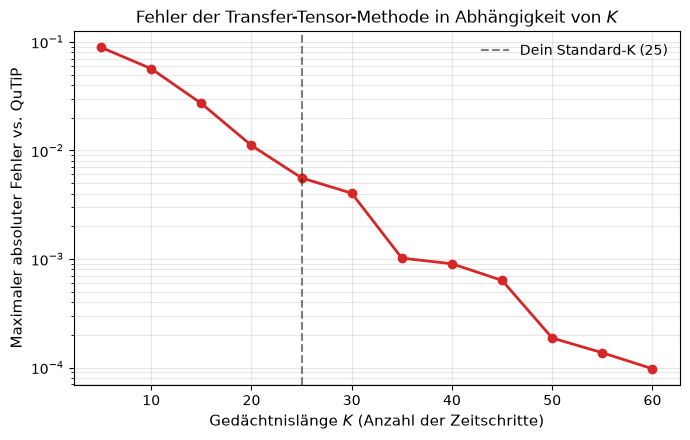

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import time

# 1. QuTiP-Referenz holen (falls in der vorherigen Zelle berechnet)
if 'HEOM_exakt (QuTiP)' in out_B:
    pops_qutip = out_B['HEOM_exakt (QuTiP)'][0]
else:
    raise ValueError("Bitte führe zuerst die Zelle mit der direkten QuTiP-Berechnung aus, damit 'pops_qutip' existiert!")

# 2. Wir testen Gedächtnislängen K von 5 bis 50 (in 5er Schritten)
K_values = np.arange(5, 61, 5)
max_K = max(K_values)
errors_K = []

print(f"Berechne Transfer-Tensoren bis maximal K={max_K} (das dauert kurz)...")
start_time = time.time()

# EFFIZIENZ-TRICK: Propagator P und maximale Maps nur EINMAL berechnen!
P, n_ado = heom_onestep_propagator(dt_fs, **MODEL, depth=HEOM_depth, verbose=False)
all_maps = heom_shorttime_maps(P, max_K, N)
if isinstance(all_maps, dict): 
    all_maps = all_maps["maps"]

print(f"Maps berechnet in {time.time() - start_time:.2f} s. Starte Schleife über K...\n")
print(f"{'K':<5} | {'Max Fehler zur QuTiP-Referenz':<30}")
print("-" * 40)

D_dim = N * N
n_steps_total = len(t_fs) - 1

# 3. Schleife über die verschiedenen Gedächtnislängen K
for K_test in K_values:
    # a) Nur die Maps bis zum aktuellen K abschneiden
    current_maps = all_maps[:K_test + 1]
    
    # b) Transfer-Tensoren und Matrix E für dieses K bauen
    T_test = transfer_tensors(current_maps, K_test)
    E_test = companion_propagator(T_test)
    
    # c) Physikalischen Startzustand X0 für dieses K aufbauen
    rho0_vec = np.zeros(D_dim, complex)
    rho0_vec[0] = 1.0  
    rho_history = [current_maps[i] @ rho0_vec for i in range(K_test)]
    X0_test = np.concatenate(rho_history[::-1])
    
    # d) Klassisch in die Zukunft propagieren
    pops_K = np.zeros((n_steps_total + 1, N))
    
    # Initialhistorie eintragen
    for i in range(K_test):
        pops_K[i, :] = np.real(np.diag(rho_history[i].reshape((N, N), order='F')))
        
    # Propagation ab K_test
    X_curr = X0_test.copy()
    for t in range(K_test, n_steps_total + 1):
        X_curr = E_test @ X_curr
        pops_K[t, :] = np.real(np.diag(X_curr[:D_dim].reshape((N, N), order='F')))
        
    # e) Fehler über die GESAMTE Trajektorie berechnen
    err = np.abs(pops_K - pops_qutip).max()
    errors_K.append(err)
    
    print(f"{K_test:<5d} | {err:<30.2e}")

# 4. Plotting des Fehlers vs. K
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.semilogy(K_values, errors_K, color='#d62728', marker='o', lw=2, markersize=6)

ax.set_title('Fehler der Transfer-Tensor-Methode in Abhängigkeit von $K$', fontsize=12)
ax.set_xlabel('Gedächtnislänge $K$ (Anzahl der Zeitschritte)', fontsize=11)
ax.set_ylabel(r'Maximaler absoluter Fehler vs. QuTiP', fontsize=11)
ax.grid(True, which='both', alpha=0.3)

# Vertikale Linie bei deinem bisherigen K = 25 zur Orientierung
ax.axvline(x=25, color='k', linestyle='--', alpha=0.5, label='Dein Standard-K (25)')
ax.legend(frameon=False)

plt.tight_layout()
plt.show()